<script>
  function code_toggle() {
    if (code_shown){
      $('div.input').hide('500');
      $('#toggleButton').val('Show Code')
    } else {
      $('div.input').show('500');
      $('#toggleButton').val('Hide Code')
    }
    code_shown = !code_shown
  }

  $( document ).ready(function(){
    code_shown=false;
    $('div.input').hide()
  });
</script>

<form action="javascript:code_toggle()">
  <input type="submit" id="toggleButton" value="Show Code">
</form>

# 07 - TSS and allele frequency correlations

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats


sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/markus/in-silico-vg-analysis


In [2]:
from config import (
    GENE_PATHS,
    VARIANT_PATHS,
    SOURCE_PALETTE,
    DISPLAY_NAMES,
    DISPLAY_NAMES_SHORT,
)
from utils.plot_utils import save_plot, autosave

NOTEBOOK_NAME = '07_TSS_and_AF_correlations'

print('\nDatasets:')
for name in ['clingen', 'clingen_null', 'background', 'background_null']:
    print(f'  {name}: {GENE_PATHS[name].name}')

BED_PATHS = {
    "clingen": "/Users/markus/university/ML-in-biotech-CB206V-ws25/data/intermediate/dataset3_ClinGen/ClinGen_gene_curation_list_GRCh38.ensg+-10kb.bed",
    "background": "/Users/markus/university/ML-in-biotech-CB206V-ws25/data/intermediate/dataset4_background/background_gene_set+-10kb.bed"
}


Datasets:
  clingen: ClinGen_HI_Gnomad_genes_19022026.parquet
  clingen_null: ClinGen_HI_Synth_genes_19022026.parquet
  background: Background_Gnomad_genes_19022026.parquet
  background_null: Background_Synth_genes_19022026.parquet


# Add TSS to gene files

In [6]:
def load_tss(bed_path: Path) -> pl.DataFrame:
    return (
        pl.read_csv(
            bed_path, separator="\t", has_header=False,
            new_columns=["chrom", "start", "end", "name"]
        )
        .select(
            pl.col("name").str.split("|").list.get(0).alias("gene_id"),
            (pl.col("start") + 10_000).alias("TSS")
        )
    )

for key in ["clingen", "background"]:
    # 1. Load fresh TSS data and existing Genes
    df_tss = load_tss(BED_PATHS[key])
    df_gene = pl.read_parquet(GENE_PATHS[key])

    # 2. Merge (Drop old TSS to prevent collision)
    if "TSS" in df_gene.columns:
        df_gene = df_gene.drop("TSS")

    df_merged = df_gene.join(df_tss, on="gene_id", how="left")

    # 3. Save
    df_merged.write_parquet(GENE_PATHS[key])
    print(f"Updated {key}: {len(df_merged)} genes saved.")

Updated clingen: 316 genes saved.
Updated background: 349 genes saved.


In [7]:
_exclude_path = PROJECT_ROOT / 'results' / 'genes_with_zero_promoter_core_variants.csv'
_exclude_df = pd.read_csv(_exclude_path)
_exclude_symbols = set(_exclude_df['gene_symbol'].dropna().tolist())

def _apply_exclusion(df: pl.DataFrame, label: str) -> pl.DataFrame:
    sym_col = 'gene_symbol' if 'gene_symbol' in df.columns else None
    id_col  = 'gene_id'     if 'gene_id'     in df.columns else None
    before = df.height
    if sym_col:
        df = df.filter(~pl.col(sym_col).is_in(_exclude_symbols))
    elif id_col:
        df = df.filter(~pl.col(id_col).is_in(_exclude_symbols))
    print(f'  {label}: removed {before - df.height} genes ({before} → {df.height})')
    return df

print(f'Applying exclusion list ({len(_exclude_symbols)} genes):')
df_hi       = _apply_exclusion(df_hi,       'ClinGen HI')
df_bg       = _apply_exclusion(df_bg,       'Background')
df_hi_synth = _apply_exclusion(df_hi_synth, 'ClinGen HI (synth)')
df_bg_synth = _apply_exclusion(df_bg_synth, 'Background (synth)')
df_real     = pl.concat([df_hi, df_bg])
df_synth    = pl.concat([df_hi_synth, df_bg_synth])


Applying exclusion list (0 genes):


NameError: name 'df_hi' is not defined

# AF vs raw score

[save_plot] Saved: figuree_AF_vs_Score_Correlations_16022026_1550.pdf
[save_plot] Saved: figuree_AF_vs_Score_Correlations_16022026_1550.svg
shape: (2, 6)
┌────────────┬─────────┬───────────────┬────────────────┬───────────────┬────────────────┐
│ Dataset    ┆ N       ┆ Pearson (Raw) ┆ Spearman (Raw) ┆ Pearson (Abs) ┆ Spearman (Abs) │
│ ---        ┆ ---     ┆ ---           ┆ ---            ┆ ---           ┆ ---            │
│ str        ┆ i64     ┆ f64           ┆ f64            ┆ f64           ┆ f64            │
╞════════════╪═════════╪═══════════════╪════════════════╪═══════════════╪════════════════╡
│ background ┆ 1999061 ┆ 0.000008      ┆ -0.000724      ┆ 0.00306       ┆ -0.008799      │
│ clingen    ┆ 1743133 ┆ 0.001203      ┆ -0.000251      ┆ 0.003648      ┆ 0.000771       │
└────────────┴─────────┴───────────────┴────────────────┴───────────────┴────────────────┘


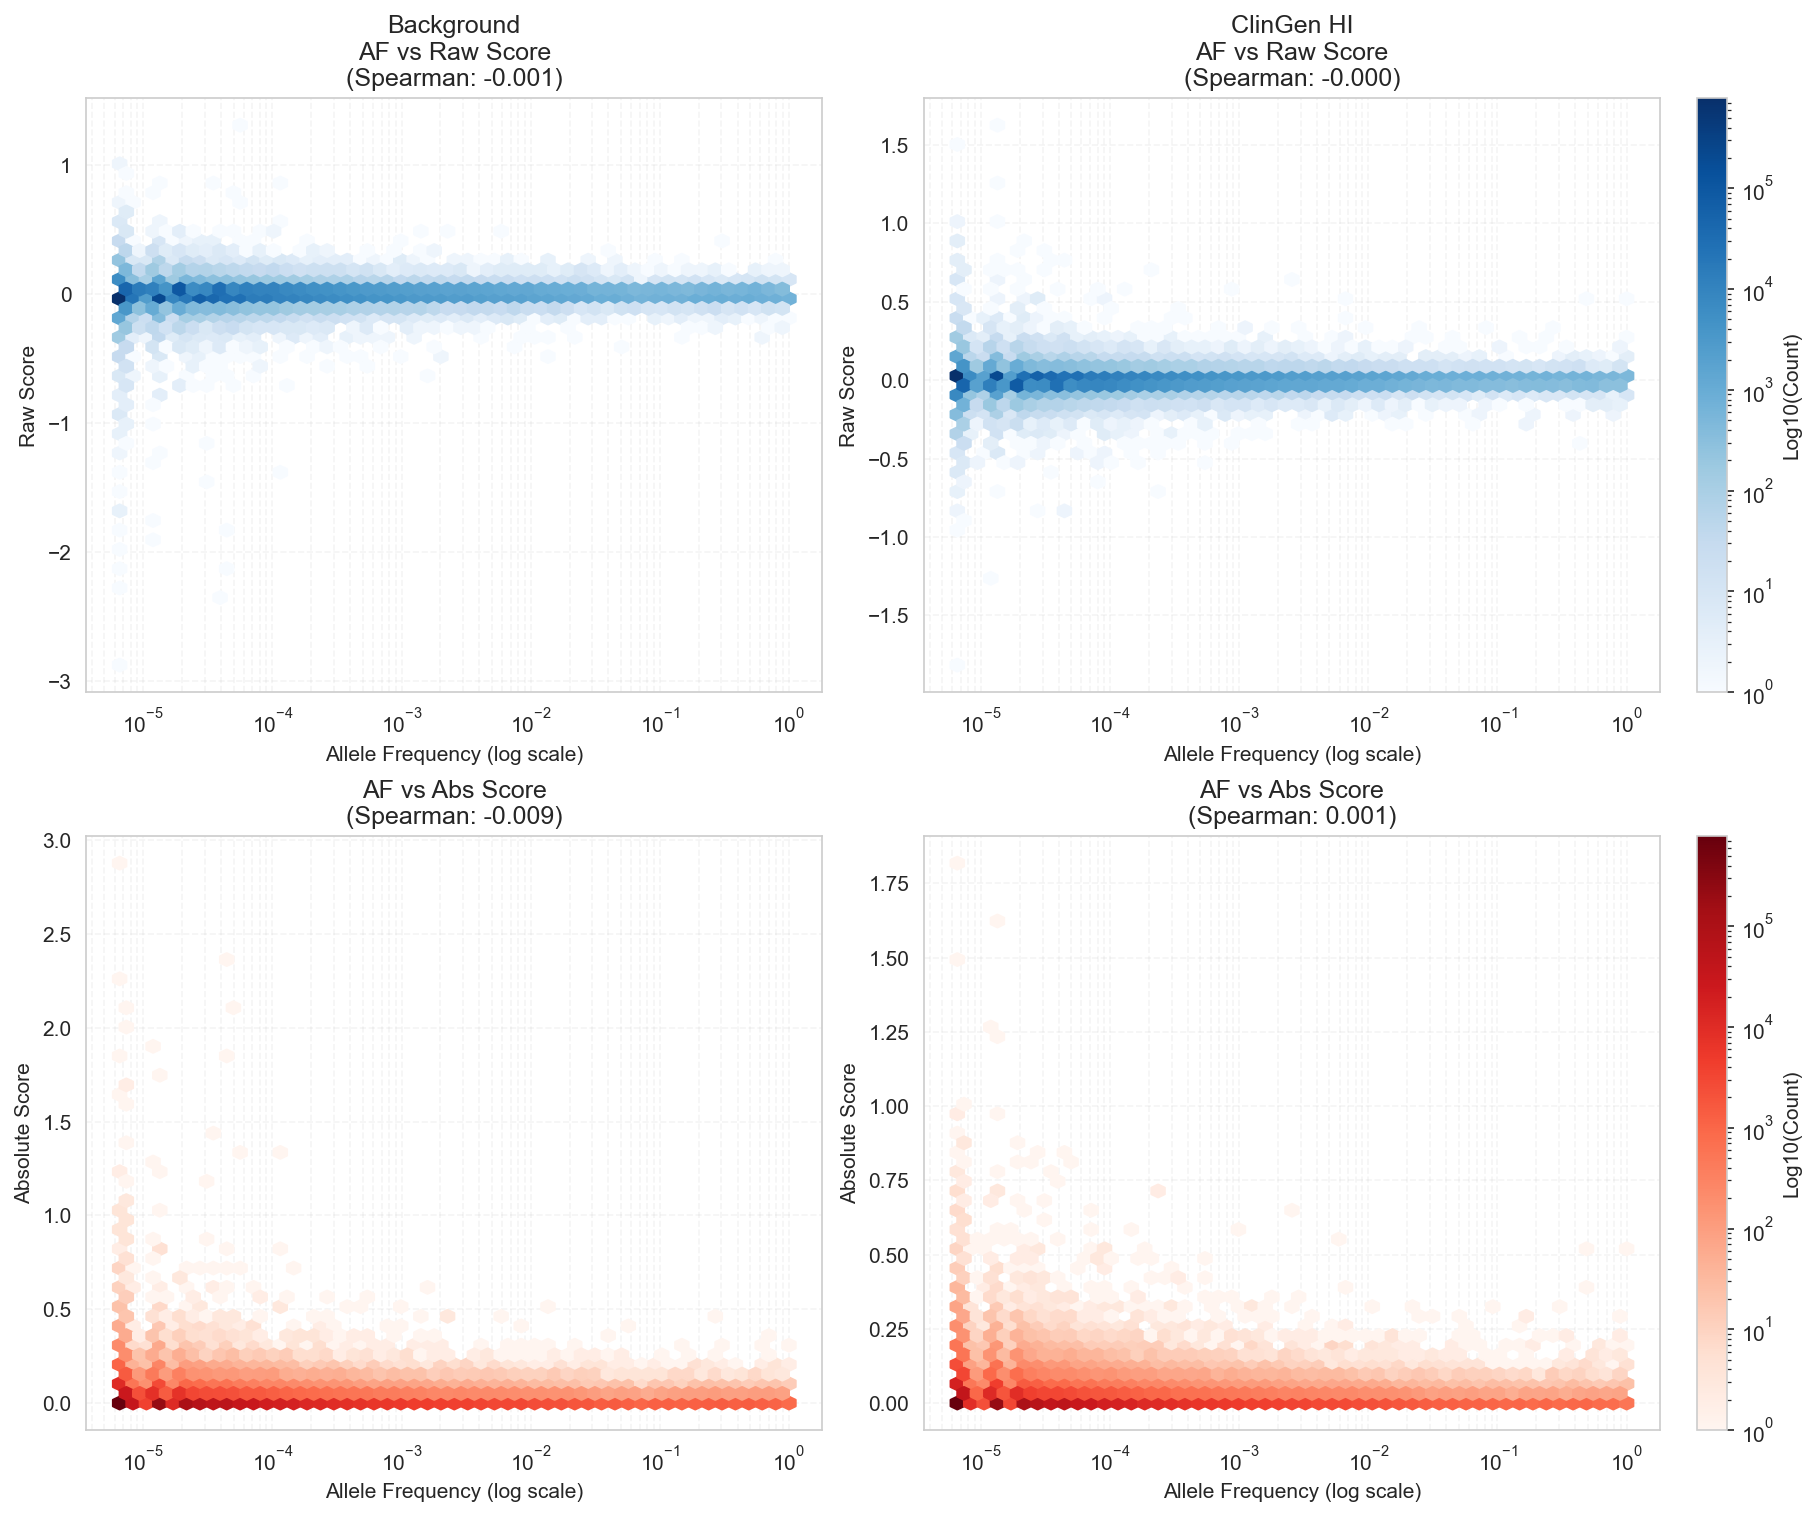

In [ ]:
def analyze_af_correlations(variant_paths: dict, palette: dict):
    datasets = [k for k in variant_paths if "null" not in k]
    results = []

    fig, axes = plt.subplots(2, len(datasets), figsize=(6 * len(datasets), 10), constrained_layout=True)
    if len(datasets) == 1: axes = np.array([axes]).T

    with autosave("AF_vs_Score_Correlations"):
        for idx, name in enumerate(datasets):
            df = pl.scan_parquet(variant_paths[name]).select(["raw_score", "AF"]).collect().drop_nulls()
            df = df.with_columns(pl.col("raw_score").abs().alias("abs_score"))

            r_raw, _ = stats.pearsonr(df["AF"], df["raw_score"])
            sp_raw, _ = stats.spearmanr(df["AF"], df["raw_score"])
            r_abs, _ = stats.pearsonr(df["AF"], df["abs_score"])
            sp_abs, _ = stats.spearmanr(df["AF"], df["abs_score"])

            results.append({
                "Dataset": name,
                "N": len(df),
                "Pearson (Raw)": r_raw, "Spearman (Raw)": sp_raw,
                "Pearson (Abs)": r_abs, "Spearman (Abs)": sp_abs
            })

            plot_df = df.filter(pl.col("AF") > 0)
            if plot_df.height > 5000000: plot_df = plot_df.sample(5000000, seed=42)

            x = plot_df["AF"].to_numpy()
            y_raw, y_abs = plot_df["raw_score"].to_numpy(), plot_df["abs_score"].to_numpy()

            ax0, ax1 = axes[0, idx], axes[1, idx]

            hb0 = ax0.hexbin(x, y_raw, gridsize=50, xscale='log', mincnt=1, cmap='Blues', bins='log')
            ax0.set_title(f"{DISPLAY_NAMES.get(name, name)}\nAF vs Raw Score\n(Spearman: {sp_raw:.3f})")
            ax0.set_xlabel("Allele Frequency (log scale)")
            ax0.set_ylabel("Raw Score")
            ax0.grid(True, which="both", ls="--", alpha=0.2)

            hb1 = ax1.hexbin(x, y_abs, gridsize=50, xscale='log', mincnt=1, cmap='Reds', bins='log')
            ax1.set_title(f"AF vs Abs Score\n(Spearman: {sp_abs:.3f})")
            ax1.set_xlabel("Allele Frequency (log scale)")
            ax1.set_ylabel("Absolute Score")
            ax1.grid(True, which="both", ls="--", alpha=0.2)

            if idx == len(datasets) - 1:
                fig.colorbar(hb0, ax=ax0).set_label('Log10(Count)')
                fig.colorbar(hb1, ax=ax1).set_label('Log10(Count)')

    print(pl.DataFrame(results))

analyze_af_correlations(VARIANT_PATHS, SOURCE_PALETTE)

[save_plot] Saved: figuree_Distance_Decay_Effect_16022026_1550.pdf
[save_plot] Saved: figuree_Distance_Decay_Effect_16022026_1550.svg
shape: (2, 3)
┌────────────┬─────────┬───────────┐
│ Dataset    ┆ N       ┆ Spearman  │
│ ---        ┆ ---     ┆ ---       │
│ str        ┆ i64     ┆ f64       │
╞════════════╪═════════╪═══════════╡
│ background ┆ 1922963 ┆ -0.288947 │
│ clingen    ┆ 1743183 ┆ -0.306383 │
└────────────┴─────────┴───────────┘


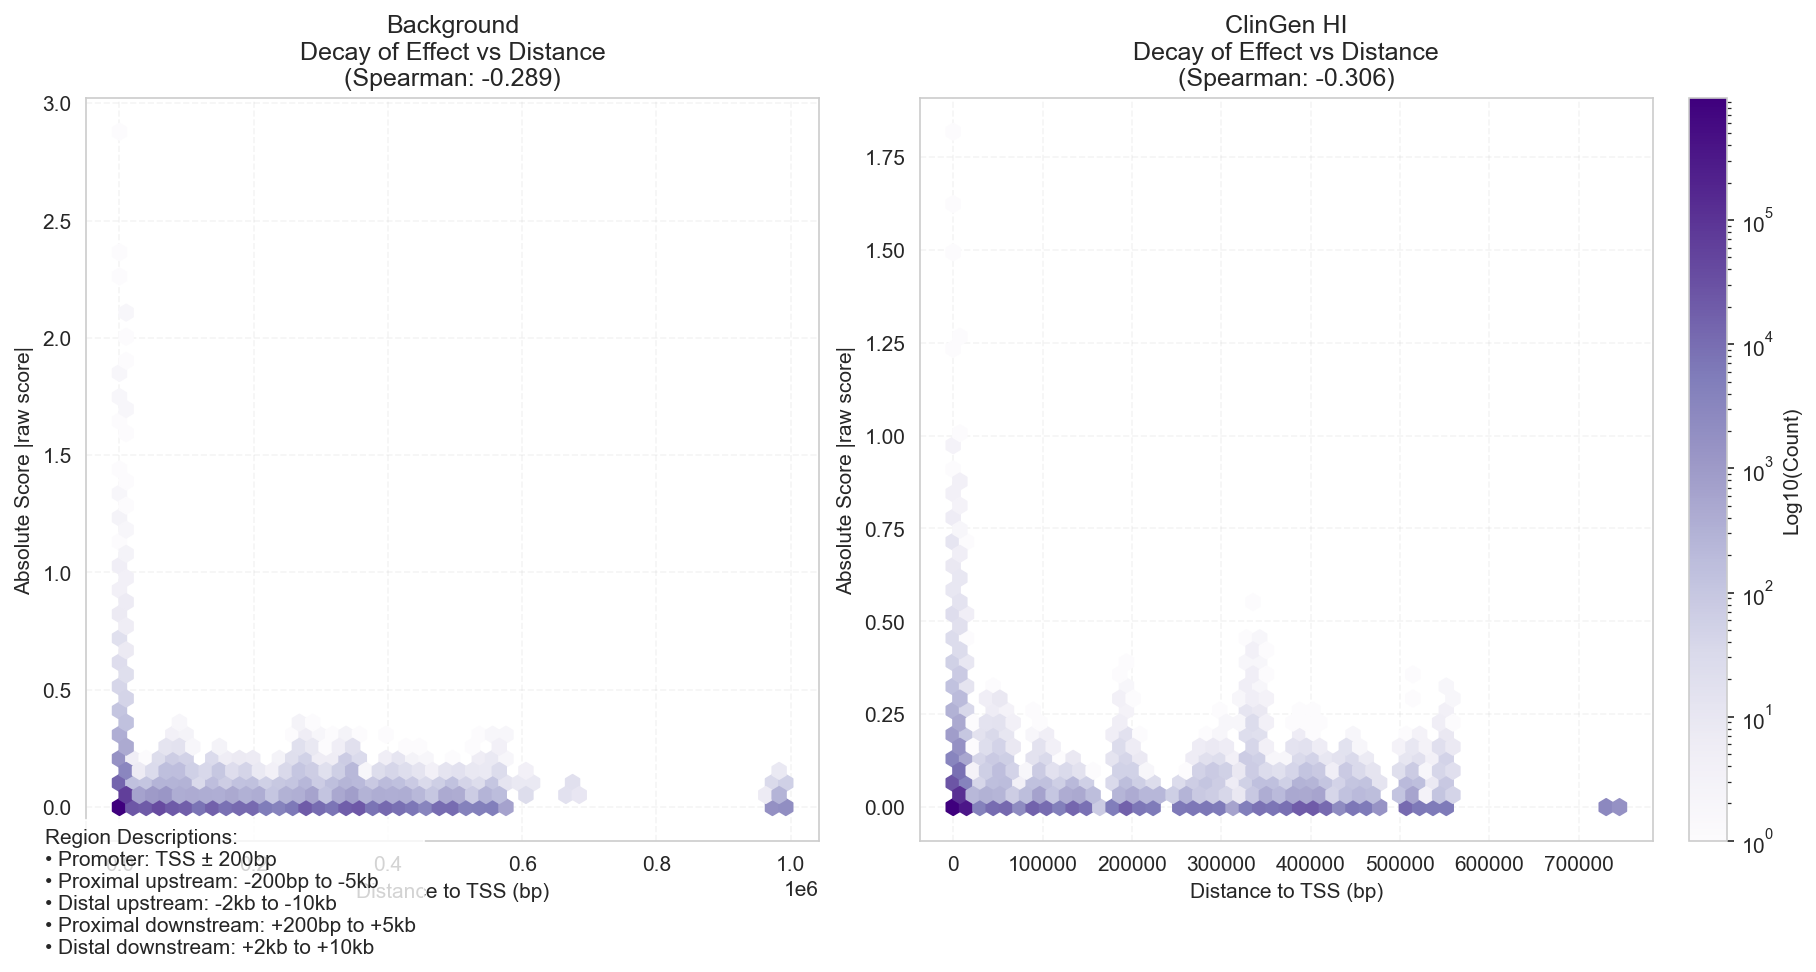

In [ ]:
def analyze_distance_correlations(variant_paths: dict, gene_paths: dict):
    datasets = [k for k in variant_paths if "null" not in k]
    results = []

    region_text = (
        "Region Descriptions:\n"
        "• Promoter: TSS ± 200bp\n"
        "• Proximal upstream: -200bp to -5kb\n"
        "• Distal upstream: -2kb to -10kb\n"
        "• Proximal downstream: +200bp to +5kb\n"
        "• Distal downstream: +2kb to +10kb"
    )

    fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 6), constrained_layout=True)
    if len(datasets) == 1: axes = [axes]

    with autosave("Distance_Decay_Effect"):
        for idx, name in enumerate(datasets):
            lf_var = pl.scan_parquet(variant_paths[name]).select(["gene_id", "POS", "raw_score"])
            lf_gene = pl.scan_parquet(gene_paths[name]).select(["gene_id", "TSS"])

            df = (
                lf_var.join(lf_gene, on="gene_id", how="inner")
                .with_columns([
                    (pl.col("POS") - pl.col("TSS")).abs().alias("dist_to_tss"),
                    pl.col("raw_score").abs().alias("abs_score")
                ])
                .collect().drop_nulls()
            )

            sp_dist, _ = stats.spearmanr(df["dist_to_tss"], df["abs_score"])
            results.append({"Dataset": name, "N": len(df), "Spearman": sp_dist})

            plot_df = df.sample(50000000, seed=42) if len(df) > 50000000 else df

            hb = axes[idx].hexbin(
                plot_df["dist_to_tss"], plot_df["abs_score"],
                gridsize=50, cmap='Purples', bins='log', mincnt=1
            )

            axes[idx].set_title(f"{DISPLAY_NAMES.get(name, name)}\nDecay of Effect vs Distance\n(Spearman: {sp_dist:.3f})")
            axes[idx].set_xlabel("Distance to TSS (bp)")
            axes[idx].set_ylabel("Absolute Score |raw score|")
            axes[idx].grid(True, which="both", ls="--", alpha=0.2)

            if idx == len(datasets) - 1:
                fig.colorbar(hb, ax=axes[idx]).set_label('Log10(Count)')

        plt.figtext(0.02, -0.05, region_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

    print(pl.DataFrame(results))

analyze_distance_correlations(VARIANT_PATHS, GENE_PATHS)

# Looking only at negative signal in CLinGen HI genes

Analyzing 'Negative Only' variants in clingen...
  Total negative variants: 866130
[save_plot] Saved: figuree_Global_Negative_Only_Trend_16022026_1550.pdf
[save_plot] Saved: figuree_Global_Negative_Only_Trend_16022026_1550.svg


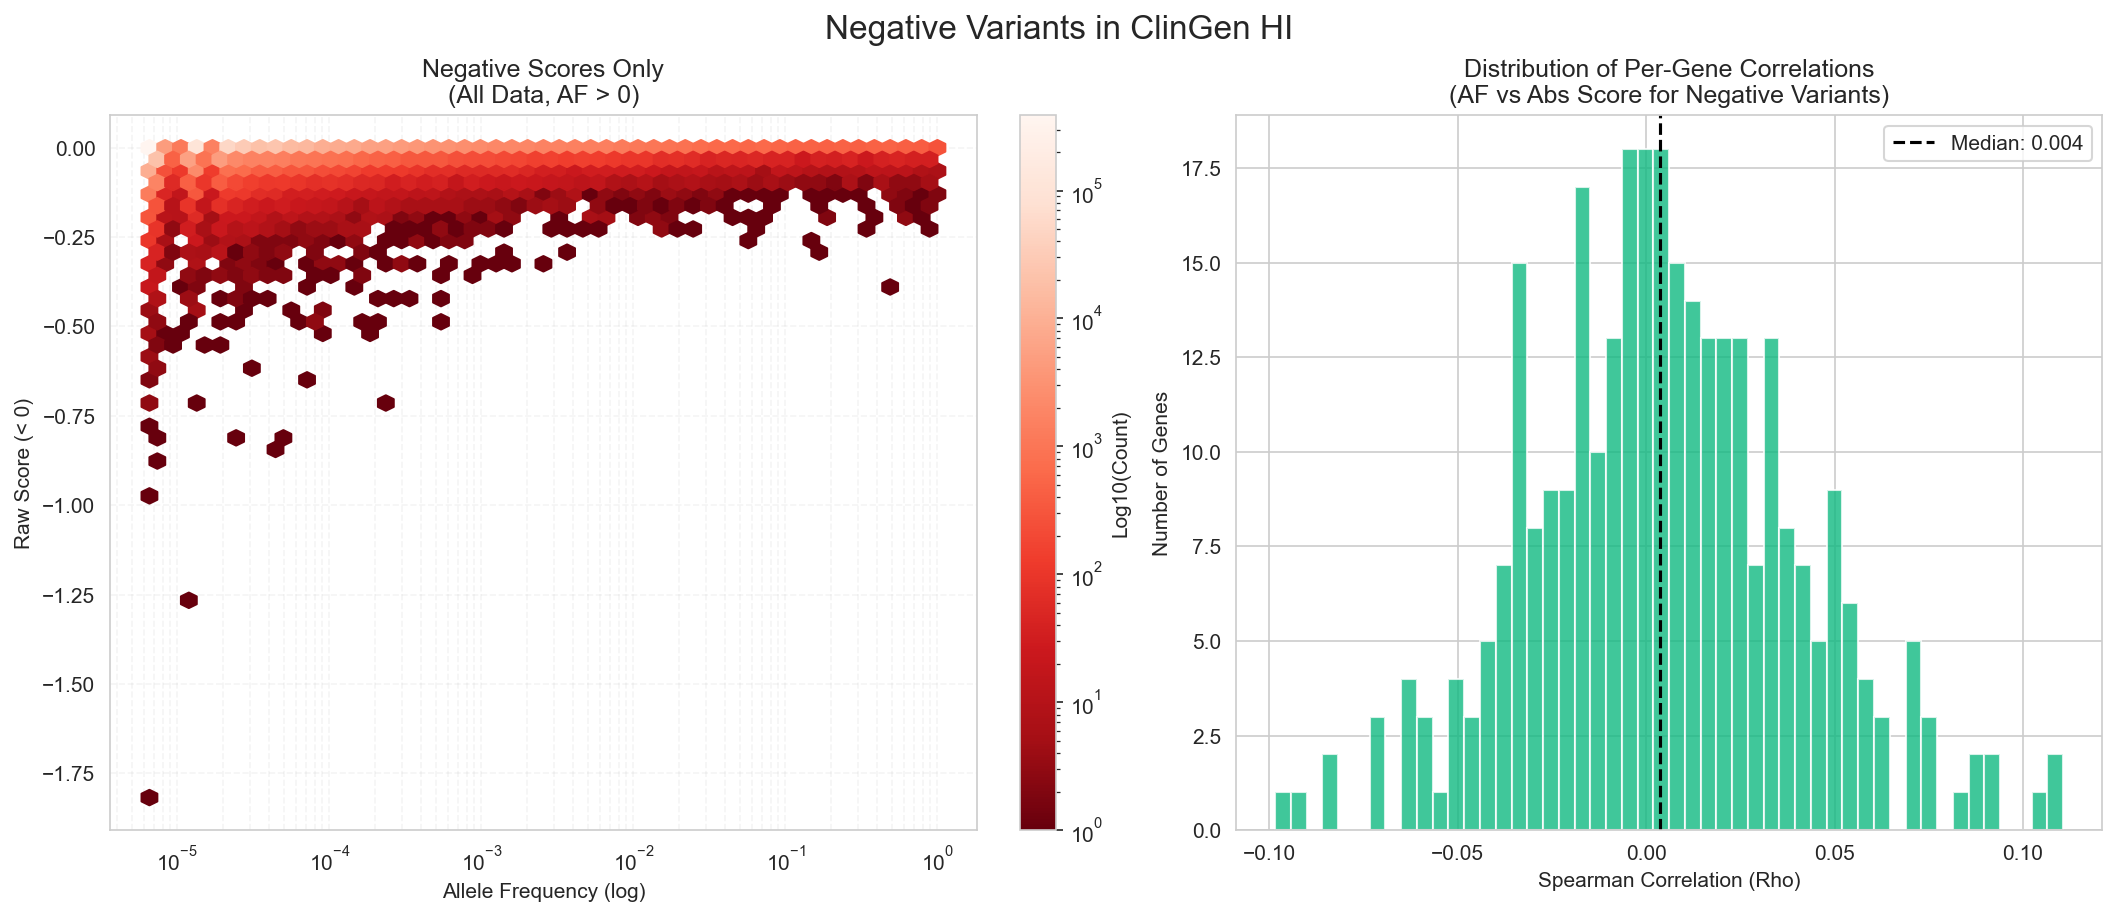


Top 10 Genes with strongest Negative Correlation:
shape: (10, 3)
┌───────────┬────────────┬───────────┐
│ gene_name ┆ n_variants ┆ rho       │
│ ---       ┆ ---        ┆ ---       │
│ str       ┆ u32        ┆ f64       │
╞═══════════╪════════════╪═══════════╡
│ PAX5      ┆ 2613       ┆ -0.098475 │
│ VHL       ┆ 2500       ┆ -0.093279 │
│ GNAS      ┆ 2157       ┆ -0.083804 │
│ NODAL     ┆ 2073       ┆ -0.083119 │
│ SH2B1     ┆ 2459       ┆ -0.071525 │
│ TMEM127   ┆ 2151       ┆ -0.071398 │
│ SETD2     ┆ 2145       ┆ -0.069604 │
│ KCNQ2     ┆ 2554       ┆ -0.06444  │
│ LDLR      ┆ 5108       ┆ -0.062848 │
│ NKX2-5    ┆ 2119       ┆ -0.061847 │
└───────────┴────────────┴───────────┘


In [ ]:
def analyze_negative_signal_per_gene(variant_paths: dict, palette: dict):
    dataset = "clingen"
    path = variant_paths[dataset]
    print(f"Analyzing 'Negative Only' variants in {dataset}...")

    # 1. Load & Filter: Raw Score < 0
    df = (
        pl.scan_parquet(path)
        .select(["gene_name", "AF", "raw_score"])
        .filter(pl.col("raw_score") < 0)
        .collect()
        .with_columns(pl.col("raw_score").abs().alias("abs_score"))
        .drop_nulls()
    )

    print(f"  Total negative variants: {len(df)}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    with autosave("Global_Negative_Only_Trend"):
        # Filter AF > 0 for log scale mapping, but keep all rows for stats
        plot_df = df.filter(pl.col("AF") > 0)

        hb = axes[0].hexbin(
            plot_df["AF"], plot_df["raw_score"],
            gridsize=50, xscale='log', mincnt=1, cmap='Reds_r', bins='log'
        )
        axes[0].set_title(f"Negative Scores Only\n(All Data, AF > 0)")
        axes[0].set_xlabel("Allele Frequency (log)")
        axes[0].set_ylabel("Raw Score (< 0)")
        axes[0].grid(True, which="both", ls="--", alpha=0.2)
        fig.colorbar(hb, ax=axes[0], label='Log10(Count)')


    per_gene_stats = (
        df.group_by("gene_name")
        .agg([
            pl.count("raw_score").alias("n_variants"),
            pl.corr("AF", "abs_score", method="spearman").alias("rho")
        ])
        .filter(pl.col("n_variants") > 10)
        .drop_nulls()
    )

    rhos = per_gene_stats["rho"].to_numpy()
    median_rho = np.median(rhos)

    axes[1].hist(rhos, bins=50, color=palette[dataset], alpha=0.8, edgecolor='white')
    axes[1].axvline(median_rho, color='black', linestyle='--', label=f'Median: {median_rho:.3f}')
    axes[1].set_title(f"Distribution of Per-Gene Correlations\n(AF vs Abs Score for Negative Variants)")
    axes[1].set_xlabel("Spearman Correlation (Rho)")
    axes[1].set_ylabel("Number of Genes")
    axes[1].legend()

    plt.suptitle("Negative Variants in ClinGen HI", fontsize=16)
    plt.show()

    top_genes = per_gene_stats.sort("rho").head(10)
    print("\nTop 10 Genes with strongest Negative Correlation:")
    print(top_genes)

analyze_negative_signal_per_gene(VARIANT_PATHS, SOURCE_PALETTE)

  N=2613 (Zero AF count: 144)
[save_plot] Saved: figuree_Gene_Trend_PAX5_16022026_1550.pdf
[save_plot] Saved: figuree_Gene_Trend_PAX5_16022026_1550.svg


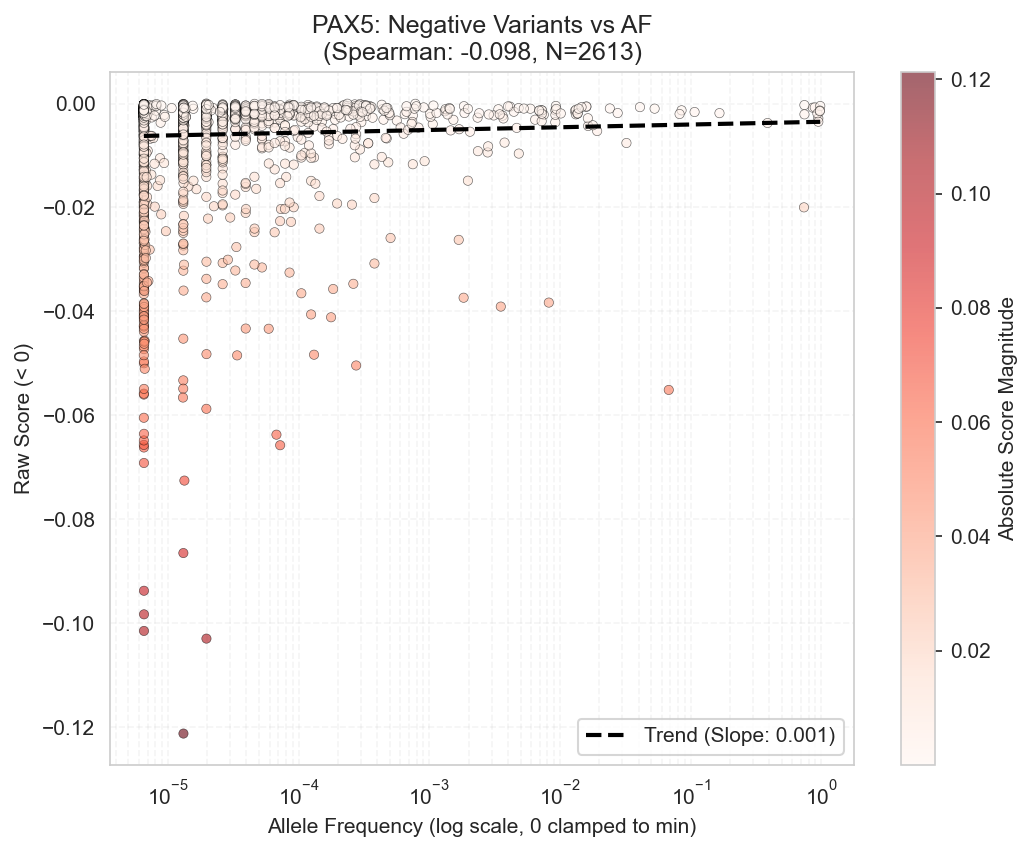

In [ ]:
from scipy.stats import linregress

def plot_specific_gene_trend(variant_paths: dict, gene_name: str):
    path = variant_paths['clingen']

    df = (
        pl.scan_parquet(path)
        .filter(pl.col("gene_name") == gene_name)
        .filter(pl.col("raw_score") < 0)
        .select(["AF", "raw_score"])
        .collect()
        .with_columns(pl.col("raw_score").abs().alias("abs_score"))
        .drop_nulls()
    )

    sp, p_val = stats.spearmanr(df["AF"], df["abs_score"])

    min_af = df.filter(pl.col("AF") > 0)["AF"].min()
    plot_af = df["AF"].to_numpy().copy()

    mask_zero = plot_af == 0
    plot_af[mask_zero] = min_af

    print(f"  N={len(df)} (Zero AF count: {mask_zero.sum()})")

    with autosave(f"Gene_Trend_{gene_name}"):
        plt.figure(figsize=(8, 6))

        sc = plt.scatter(
            plot_af, df["raw_score"],
            alpha=0.6, c=df["abs_score"],
            cmap="Reds", edgecolors='k', linewidth=0.3, s=20
        )

        log_af = np.log10(plot_af)
        slope, intercept, _, _, _ = linregress(log_af, df["raw_score"])

        x_trend = np.logspace(np.log10(min_af), np.log10(plot_af.max()), 100)
        y_trend = slope * np.log10(x_trend) + intercept

        plt.plot(x_trend, y_trend, color='black', linestyle='--', lw=2, label=f'Trend (Slope: {slope:.3f})')

        plt.title(f"{gene_name}: Negative Variants vs AF\n(Spearman: {sp:.3f}, N={len(df)})")
        plt.xlabel("Allele Frequency (log scale, 0 clamped to min)")
        plt.ylabel("Raw Score (< 0)")
        plt.xscale('log')
        plt.grid(True, which="both", ls="--", alpha=0.2)
        plt.legend()
        plt.colorbar(sc, label="Absolute Score Magnitude")

    plt.show()

plot_specific_gene_trend(VARIANT_PATHS, "PAX5")

# ClinGen HI gene level depletion

[save_plot] Saved: figuree_Purging_Effect_Linear_16022026_1550.pdf
[save_plot] Saved: figuree_Purging_Effect_Linear_16022026_1550.svg


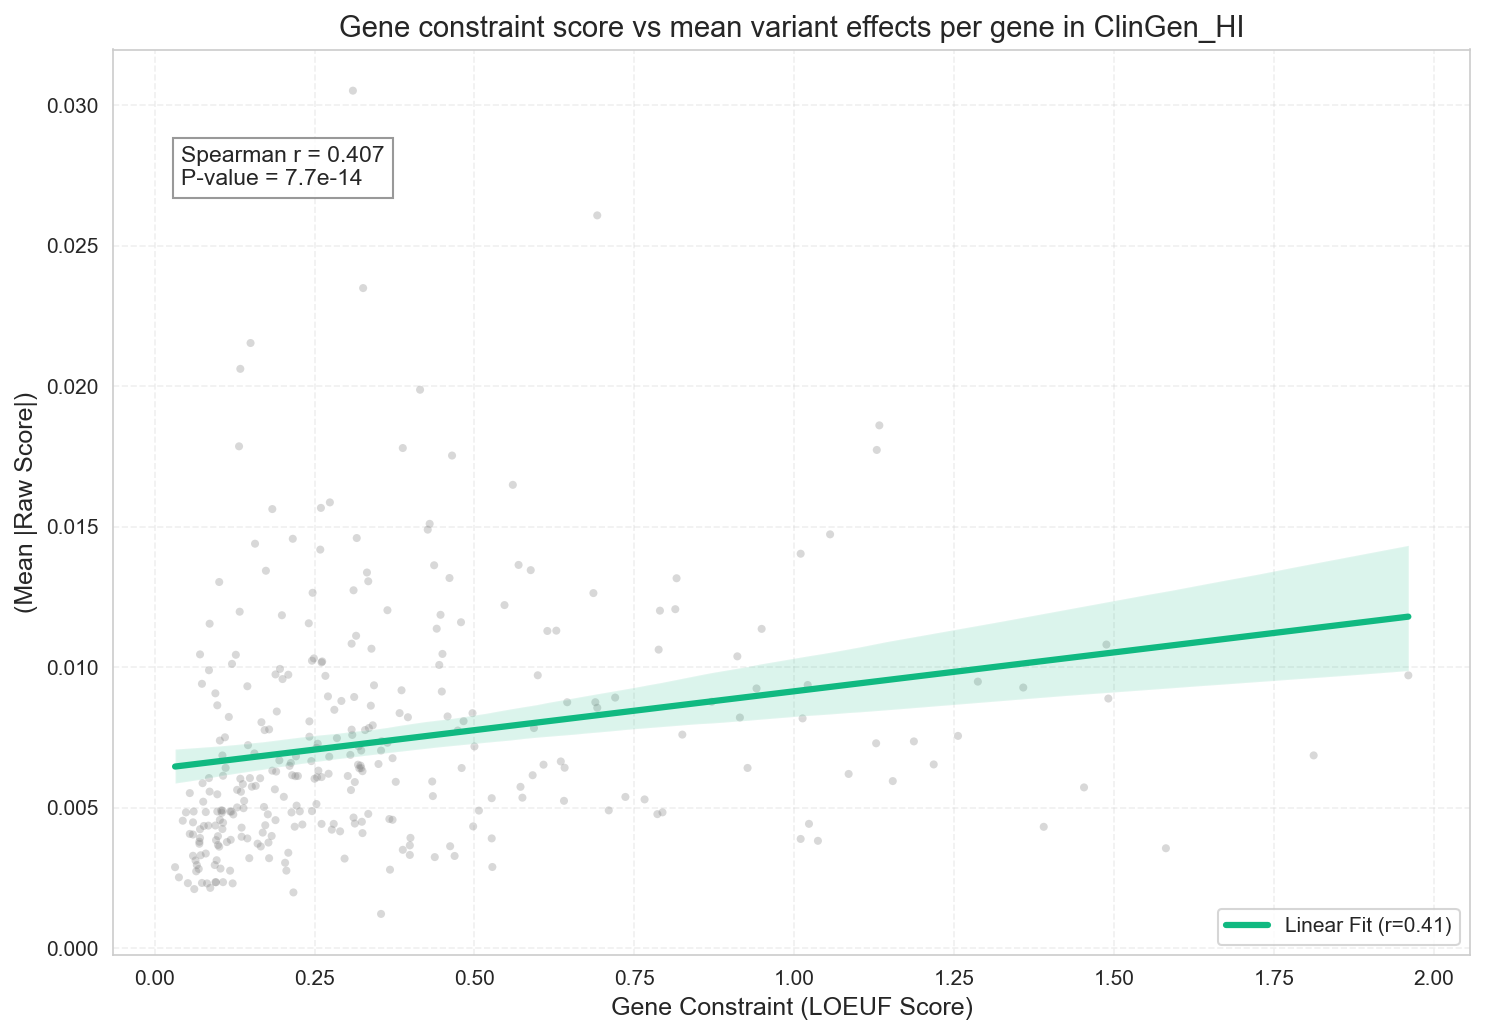

Stats:
  Spearman r=0.4070, p=7.6856e-14
  Mann-Whitney (Top vs Bottom 10%): p=1.9735e-07


In [ ]:
def analyze_purging_linear(variant_paths: dict, gene_paths: dict, palette: dict):
    dataset = "clingen"
    df_genes = pl.read_parquet(gene_paths[dataset]).select(["gene_symbol", "loeuf_score"]).drop_nulls()

    per_gene_scores = (
        pl.scan_parquet(variant_paths[dataset])
        .filter(pl.col("AF") < 0.05)
        .filter(pl.col("raw_score") < 0)
        .select(["gene_name", "raw_score"])
        .with_columns(pl.col("raw_score").abs().alias("abs_score"))
        .group_by("gene_name")
        .agg(pl.col("abs_score").mean().alias("mean_abs_score"))
        .collect()
    )

    df = (
        per_gene_scores
        .join(df_genes, left_on="gene_name", right_on="gene_symbol", how="inner")
        .to_pandas()
    )

    r, p_corr = stats.spearmanr(df['loeuf_score'], df['mean_abs_score'])

    # Mann-Whitney U (Top 10% vs Bottom 10%)
    q10 = df['loeuf_score'].quantile(0.10)
    q90 = df['loeuf_score'].quantile(0.90)
    group_constrained = df[df['loeuf_score'] <= q10]['mean_abs_score']
    group_tolerant = df[df['loeuf_score'] >= q90]['mean_abs_score']
    u_stat, p_mw = stats.mannwhitneyu(group_constrained, group_tolerant, alternative='less')

    with autosave("Purging_Effect_Linear"):
        fig, ax = plt.subplots(figsize=(10, 7))

        sns.regplot(
            data=df,
            x='loeuf_score',
            y='mean_abs_score',
            ci=95,
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'gray', 'edgecolor': 'none'},
            line_kws={'color': palette[dataset], 'lw': 3, 'label': f'Linear Fit (r={r:.2f})'},
            ax=ax
        )

        ax.set_title("Gene constraint score vs mean variant effects per gene in ClinGen_HI", fontsize=14)
        ax.set_xlabel("Gene Constraint (LOEUF Score)", fontsize=12)
        ax.set_ylabel("(Mean |Raw Score|)", fontsize=12)

        stats_text = (
            f"Spearman r = {r:.3f}\n"
            f"P-value = {p_corr:.1e}"
        )
        ax.text(0.05, 0.85, stats_text, transform=ax.transAxes,
                fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

        #ax.text(0.05, 0.95, "Purged Zone", transform=ax.transAxes,
        #        color='red', fontsize=11, fontweight='bold', alpha=0.7)
        #ax.text(0.95, 0.95, "Tolerant Zone", transform=ax.transAxes,
        #        ha='right', color='green', fontsize=11, fontweight='bold', alpha=0.7)

        ax.grid(True, which="major", ls="--", alpha=0.3)
        ax.legend(loc='lower right')
        plt.tight_layout()

    plt.show()

    print(f"Stats:\n  Spearman r={r:.4f}, p={p_corr:.4e}")
    print(f"  Mann-Whitney (Top vs Bottom 10%): p={p_mw:.4e}")

analyze_purging_linear(VARIANT_PATHS, GENE_PATHS, SOURCE_PALETTE)

# I am thinking within a single gene (where LOEUF is constant). Calculate the top 10 percentile for absolute effect sizes per gene. The look in all variants with AF > i.e 0.05 and check if variants in that top 10 percentile are enriched or depleted in that set

  Analyzed 310 genes.
[save_plot] Saved: figuree_Local_Relative_Depletion_16022026_1550.pdf
[save_plot] Saved: figuree_Local_Relative_Depletion_16022026_1550.svg


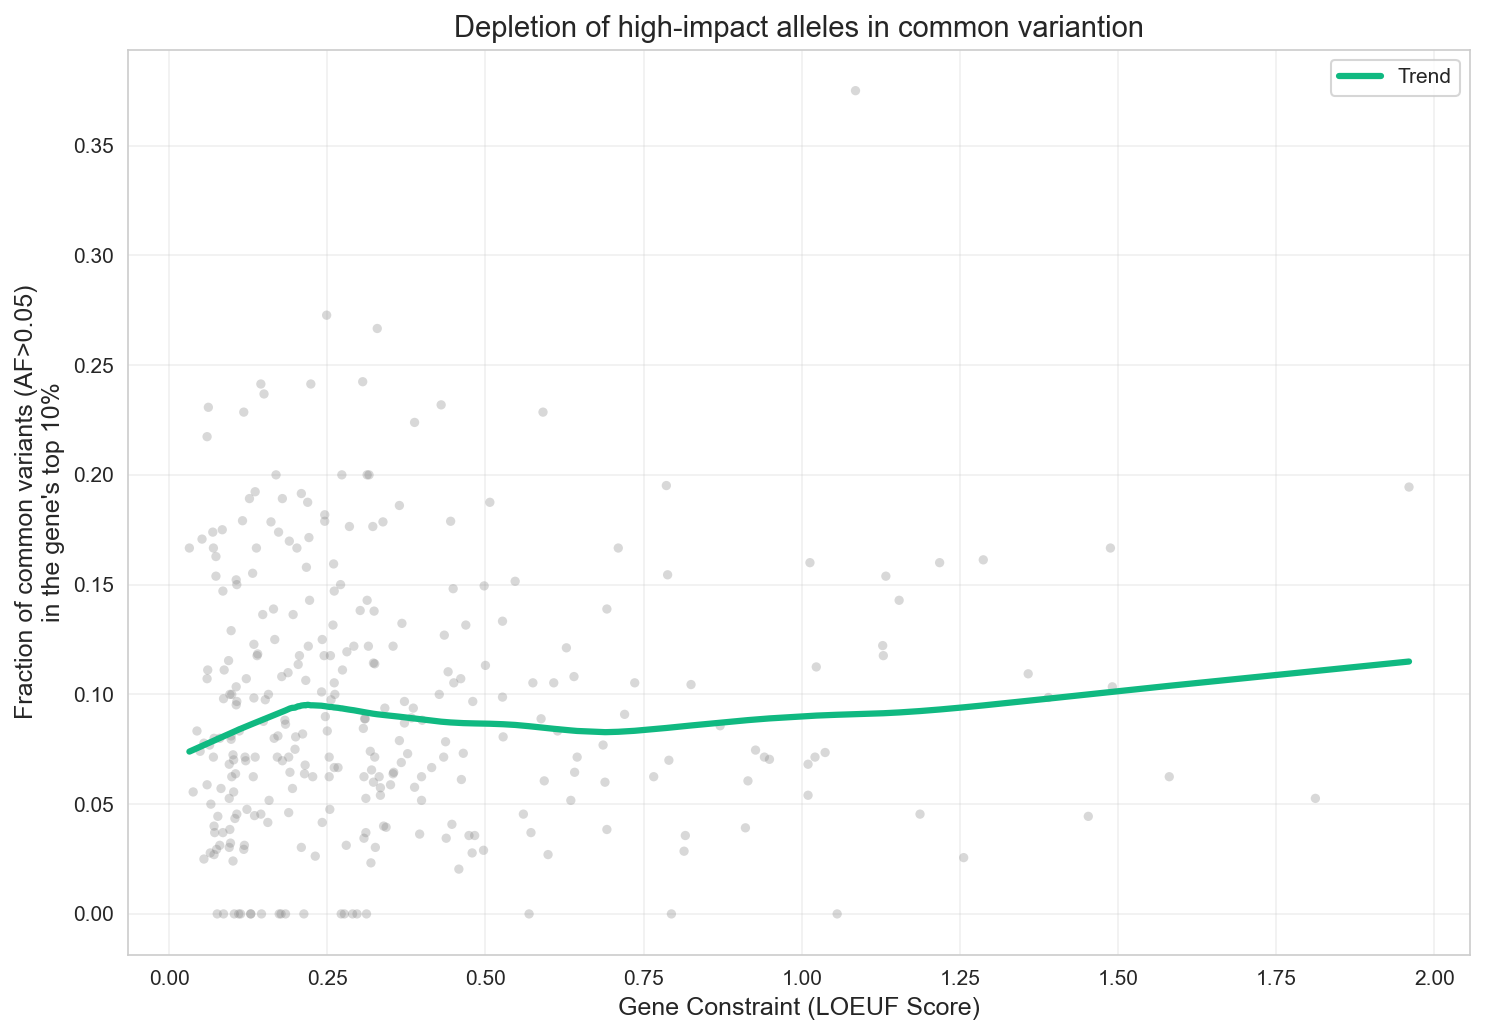

Spearman correlation: r=0.0373, p=5.1259e-01


In [ ]:
def analyze_local_relative_depletion(variant_paths: dict, gene_paths: dict, palette: dict):
    dataset = "clingen"
    df_genes = pl.read_parquet(gene_paths[dataset]).select(["gene_symbol", "loeuf_score"]).drop_nulls()

    df_variants = pl.scan_parquet(variant_paths[dataset]).select(["gene_name", "AF", "raw_score"])

    per_gene_metrics = (
        df_variants
        .with_columns(pl.col("raw_score").abs().alias("abs_score"))
        .with_columns(
            pl.col("abs_score").quantile(0.90).over("gene_name").alias("local_p90_threshold")
        )

        .group_by("gene_name")
        .agg([
            (pl.col("AF") > 0.05).sum().alias("n_common_total"),

            (
                (pl.col("AF") > 0.05) &
                (pl.col("abs_score") >= pl.col("local_p90_threshold"))
            ).sum().alias("n_common_in_local_top10")
        ])
        .filter(pl.col("n_common_total") >= 5)

        .with_columns(
            (pl.col("n_common_in_local_top10") / pl.col("n_common_total")).alias("prop_common_top10")
        )
        .collect()
    )

    df = per_gene_metrics.join(df_genes, left_on="gene_name", right_on="gene_symbol", how="inner").to_pandas()
    print(f"  Analyzed {len(df)} genes.")

    with autosave("Local_Relative_Depletion"):
        fig, ax = plt.subplots(figsize=(10, 7))

        # If selection didn't care about the score, 10% of common variants
        # would fall in the top 10% of scores.
        #ax.axhline(0.10, color='red', linestyle='--', alpha=0.5, label='Neutral Expectation (10%)')

        sns.regplot(
            data=df,
            x='loeuf_score',
            y='prop_common_top10',
            lowess=True,
            scatter_kws={'alpha': 0.3, 's': 20, 'color': 'gray', 'edgecolor': 'none'},
            line_kws={'color': palette[dataset], 'lw': 3, 'label': 'Trend'},
            ax=ax
        )

        ax.set_title("Depletion of high-impact alleles in common variantion", fontsize=14)
        ax.set_xlabel("Gene Constraint (LOEUF Score)", fontsize=12)
        ax.set_ylabel("Fraction of common variants (AF>0.05)\nin the gene's top 10%", fontsize=12)

        # Interpretation Helper
        #ax.text(0.05, 0.9, "Below 0.10 = Depletion\nThe 'worst' variants are\nkept rare by selection",
        #        transform=ax.transAxes, color='blue', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()

    plt.show()

    r, p = stats.spearmanr(df['loeuf_score'], df['prop_common_top10'])
    print(f"Spearman correlation: r={r:.4f}, p={p:.4e}")

analyze_local_relative_depletion(VARIANT_PATHS, GENE_PATHS, SOURCE_PALETTE)